In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Dataset with target variances for the first two features (~60 and ~15)
np.random.seed(0)
n = 10
f1 = np.random.normal(0, np.sqrt(60), n)
f2 = np.random.normal(0, np.sqrt(15), n)
f3 = np.random.normal(0, 1.0, n)  # third feature for 3D compatibility

X = np.column_stack((f1, f2, f3))


X.shape

(10, 3)

In [3]:
X.shape

(10, 3)

# 3d visualization of the dataset 

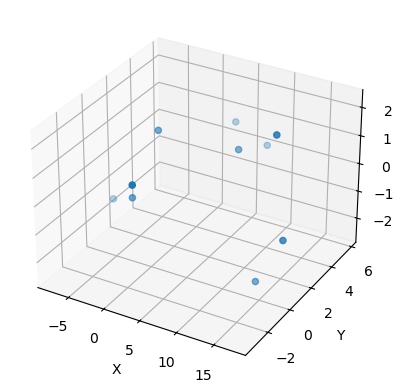

In [4]:
x = X[:,0]
y = X[:,1]
z = X[:,2]

# create 3D plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x, y, z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [5]:

# Step 1: Center the data (important for PCA)
X_centered = X - X.mean(axis=0)

# Step 2: Apply Singular Value Decomposition
U, S, Vt = np.linalg.svd(X_centered)

# Step 3: Principal components (directions)
c1 = Vt[0]   # First principal component
c2 = Vt[1]   # Second principal component
c3 = Vt[2]   # Third principal component

print("Principal Component 1:", c1)
print("Principal Component 2:", c2)
print("Principal Component 3:", c3)


Principal Component 1: [-0.99958937 -0.02837386  0.00400156]
Principal Component 2: [-0.0282841   0.99938054  0.02094134]
Principal Component 3: [-0.00459327  0.02081956 -0.9997727 ]


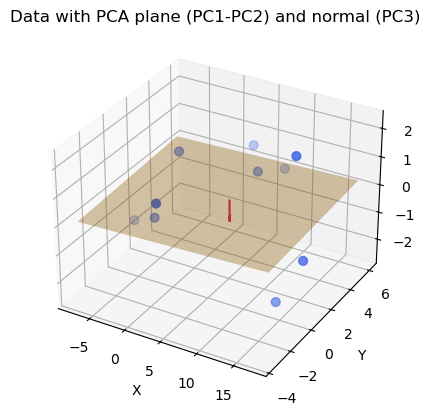

In [6]:

# Build a plane spanned by PC1 and PC2, centered at the data mean
mu = X.mean(axis=0)
scores = X_centered @ Vt.T  # coordinates in PC space

u = np.linspace(scores[:, 0].min(), scores[:, 0].max(), 25)
v = np.linspace(scores[:, 1].min(), scores[:, 1].max(), 25)
U_grid, V_grid = np.meshgrid(u, v)

plane = mu + U_grid[..., None] * c1 + V_grid[..., None] * c2
Xp, Yp, Zp = plane[..., 0], plane[..., 1], plane[..., 2]

# 3D scatter + PCA plane
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x, y, z, color='royalblue', s=40)
ax.plot_surface(Xp, Yp, Zp, alpha=0.35, color='orange', edgecolor='none')

# PC3 is orthogonal (normal) to the PC1-PC2 plane
scale = 0.8
ax.quiver(mu[0], mu[1], mu[2], c3[0], c3[1], c3[2], color='crimson', length=scale, normalize=True)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Data with PCA plane (PC1-PC2) and normal (PC3)")
plt.show()

#  Reduce Matrix 

## Reduce Matrix (PCA Projection)

$$
X_{\text{reduced}} = X_{\text{centered}} W_d
$$

where

$$
W_d =
\begin{bmatrix}
\text{PC}_1 & \text{PC}_2
\end{bmatrix}
$$

- \(W_d\): matrix of the top \(d\) principal components (here \(d=2\))
- \(\text{PC}_1 = c_1\), \(\text{PC}_2 = c_2\)
- \(X_{\text{reduced}}\): low-dimensional representation of \(X\)

In [7]:
# W_d = W_2 (dimension is 2 )

W2 = Vt[:2].T 
X_2d = X_centered@W2

dimensionality reduction using scikit learn 

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

X_2d.shape  # shape is reduced of 3d to 2d 

(10, 2)

Variance Ratio of PC in dataset


In [9]:
var_ratio = pca.explained_variance_ratio_
print("the variance ratio is:",var_ratio)

the variance ratio is: [0.86544326 0.10424942]


Right number of dimensions

In [10]:
# ...existing code...
pca = PCA()  # all components
pca.fit(X)

cumsum = np.cumsum(pca.explained_variance_ratio_)
target = 0.95
d = np.searchsorted(cumsum, target) + 1

print(f"Minimum number of components to retain at least {int(target*100)}% variance: {d}")
# ...existing code...

Minimum number of components to retain at least 95% variance: 2


we can also define the n_component "number of dimensions " by defining </b>
ratio of variance instead of number of dimensions 

In [11]:
pca = PCA(n_components=0.88 ) # ratio of variance(minimum to preverse)
pca.fit_transform(X) 

n_d =pca.n_components_
print("number of dimensions",n_d)

number of dimensions 2


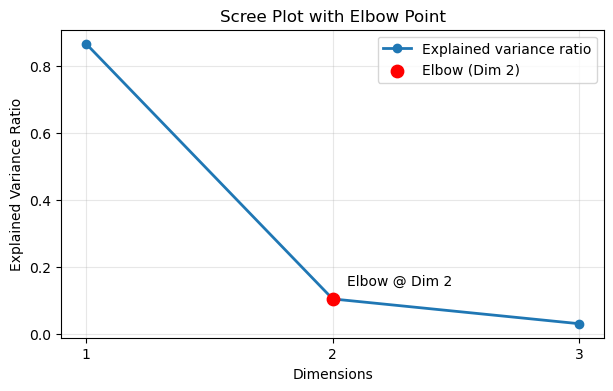

In [12]:
# Scree plot: explained variance vs dimensions, with elbow point
pca_full = PCA()
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
dims = np.arange(1, len(explained_var) + 1)

# Simple elbow detection using 2nd difference (works well for scree-like curves)
if len(explained_var) >= 3:
    elbow_dim = np.argmax(np.abs(np.diff(explained_var, n=2))) + 2
else:
    elbow_dim = 1

plt.figure(figsize=(7, 4))
plt.plot(dims, explained_var, marker='o', linewidth=2, label='Explained variance ratio')
plt.scatter(elbow_dim, explained_var[elbow_dim - 1], color='red', s=80, zorder=5, label=f'Elbow (Dim {elbow_dim})')
plt.annotate(
    f'Elbow @ Dim {elbow_dim}',
    (elbow_dim, explained_var[elbow_dim - 1]),
    textcoords="offset points",
    xytext=(10, 10)
)

plt.xticks(dims)
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot with Elbow Point")
plt.grid(alpha=0.3)
plt.legend()
plt.show()